In [ ]:
# PART 1) 설정 및 초기화 (Configuration & Setup)
# - 라이브러리 임포트
# - 하이퍼파라미터 정의 (learning rate, batch size, epochs…)
# - 랜덤 시드 고정 (reproducibility)
# - 디바이스 설정 (CPU/GPU)
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models

def set_seed(seed_num=42):
    random.seed(seed_num)
    np.random.seed(seed_num)
    torch.manual_seed(seed_num)                     # CPU
    torch.cuda.manual_seed(seed_num)                # GPU
    torch.backends.cudnn.deterministic = True       # 연산 결정적 수행
    torch.backends.cudnn.benchmark = False          # 성능 최적화 비활성화 (재현성 확보)

# 하이퍼파라미터 설정
batch_size = 32
seed_num = 42
set_seed(seed_num)

num_epochs = 50
learning_rate = 0.01
weight_decay = 1e-4
momentum = 0.9

# 클래스 수 설정
num_super = 5
num_main = 15
num_sub = 31

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import shutil

drive_dir = "/content/drive/MyDrive/DERM12345_images"
local_dir = "/content/DERM12345_images"

os.makedirs(local_dir, exist_ok=True)
for root, dirs, files in os.walk(drive_dir):
  for file in files:
    if file.lower().endswith('.jpg'):
      src = os.path.join(root, file)
      rel_path = os.path.relpath(src, drive_dir)
      dst = os.path.join(local_dir, rel_path)

      os.makedirs(os.path.dirname(dst), exist_ok=True)
      if not os.path.exists(dst):
        shutil.copy2(src, dst)

In [ ]:
# DERM12345 데이터셋과 메타데이터 불러오기
drive_dir = '/content/drive/My Drive'
local_dir = '/content/DERM12345_images'

train_metadata_path = os.path.join(drive_dir, 'derm12345_metadata_train.csv')
test_metadata_path = os.path.join(drive_dir, 'derm12345_metadata_test.csv')

train_df = pd.read_csv(train_metadata_path)
test_df = pd.read_csv(test_metadata_path)

train_df['img_path'] = train_df['image_id'].apply(lambda x : os.path.join(local_dir, "derm12345_train", f"{x}.jpg"))
test_df['img_path'] = test_df['image_id'].apply(lambda x : os.path.join(local_dir, "derm12345_test", f"{x}.jpg"))

print("훈련 메타데이터")
print(train_df.head())

print("\n테스트 메타데이터")
print(test_df.head())

missing_train = (~train_df['img_path'].apply(os.path.exists)).sum()
missing_test = (~test_df['img_path'].apply(os.path.exists)).sum()

print(f'\n✅ Missing train files: {missing_train}')
print(f'✅ Missing test files : {missing_test}')

In [ ]:
# PART 2) 데이터 준비 (Data Preparation)
# - 이미지에 Transform 적용
# - 커스텀 DermDataset 정의

import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 학습 데이터용 transform (증강 포함)
train_transform = transforms.Compose([
    transforms.Resize(224), # 224 x 224
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # 원본 이미지에서 80%~100% 까지 잘라낸 뒤, 지정된 출력 크기로 리사이즈
    transforms.RandomHorizontalFlip(),      # 50% 확률로 좌우 반전
    transforms.RandomRotation(15),          # -15도 ~ +15도 사이로 랜덤 회전
    # === TrivialAugmentWide 추가 ===
    # 이 부분에서 다양한 무작위 변환(색상, 전단, 포스터화 등)
    transforms.TrivialAugmentWide(),
    # ===============================
    transforms.ToTensor(),                  # 이미지를 텐서로 변화
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# 검증/테스트 데이터용 transform (증강 X,)
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

class DermDataset(Dataset):
  def __init__(self, df, super_to_idx, main_to_idx, sub_to_idx, transform=None):
    self.df = df
    self.transform = transform
    self.super_to_idx = super_to_idx
    self.main_to_idx = main_to_idx
    self.sub_to_idx = sub_to_idx

    self.idx_to_class = {v: k for k, v in self.sub_to_idx.items()} # index to subclass

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_path = self.df.iloc[idx]['img_path']
    image = Image.open(img_path).convert("RGB")

    y_super_name = f"{self.df.iloc[idx]['super_class']} {self.df.iloc[idx]['malignancy']}"
    y_main_name = f"{self.df.iloc[idx]['main_class_1']} {self.df.iloc[idx]['main_class_2']} in {self.df.iloc[idx]['super_class']} {self.df.iloc[idx]['malignancy']}"
    y_sub_name = self.df.iloc[idx]['label_grouped'] # subclass label name

    y_super = self.super_to_idx[y_super_name]
    y_main = self.main_to_idx[y_main_name]
    y_sub = self.sub_to_idx[y_sub_name]

    if self.transform:
      image = self.transform(image)

    return image, (y_super, y_main, y_sub)

# 그룹핑
subclass_counts = train_df['label'].value_counts()
RARE_THRESHOLD = 15
rare_classes = subclass_counts[subclass_counts < RARE_THRESHOLD].index.tolist()
print(f"RARE CLASSES SIZE : {len(rare_classes)}")

def group_rare_subclasses(label):
  return "rare" if label in rare_classes else label

train_df['label_grouped'] = train_df['label'].apply(group_rare_subclasses)
test_df['label_grouped'] = test_df['label'].apply(group_rare_subclasses)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=seed_num,
    stratify=train_df['label']
)

# class to index 정의
super_to_idx = {
    cls: idx for idx, cls in enumerate(
        sorted((train_df['super_class'] + " " + train_df['malignancy']).unique())
    )
}

main_to_idx = {
    cls: idx for idx, cls in enumerate(
        sorted((train_df['main_class_1'] + " " + train_df['main_class_2'] + " in "
                + train_df['super_class'] + " " + train_df['malignancy']).unique())
    )
}

sub_to_idx = {
    cls: idx for idx, cls in enumerate(sorted(train_df['label_grouped'].unique()))
}

# DermDataset 생성
train_dataset = DermDataset(train_df, super_to_idx, main_to_idx, sub_to_idx, train_transform)
val_dataset = DermDataset(val_df, super_to_idx, main_to_idx, sub_to_idx, test_transform)
test_dataset = DermDataset(test_df, super_to_idx, main_to_idx, sub_to_idx, test_transform)

# WeightedRandomSampler 사용
targets = train_df['label_grouped'].tolist()
target_counts = pd.Series(targets).value_counts()

ordered_targets = sub_to_idx.keys()

ordered_counts = [
    target_counts.get(target, 0)
    for target in ordered_targets
]
ordered_counts_tensor = torch.tensor(ordered_counts, dtype=torch.float)

epsilon = 1e-9
class_weights = 1.0 / (ordered_counts_tensor + epsilon)

# 정규화 (평균이 1이 되게)
class_weights = class_weights / class_weights.mean()
class_weights = torch.clamp(class_weights, 0.2, 6.0)

sample_weights = [class_weights[sub_to_idx[target]] for target in targets]
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoader로 묶기
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=2, pin_memory=True)

In [ ]:
# cell 5 바로 뒤에 추가하여 실행
print("\n[그룹화된 최종 서브클래스 목록]")
print(sorted(sub_to_idx.keys()))
print(f"총 클래스 수: {len(sub_to_idx.keys())}")


[그룹화된 최종 서브클래스 목록]
['acb', 'ajb', 'ajd', 'ak', 'alm', 'angk', 'anm', 'bcc', 'bd', 'bdb', 'cb', 'ccb', 'ccd', 'cd', 'cjb', 'db', 'df', 'ha', 'jb', 'jd', 'la', 'lm', 'lmm', 'ls', 'mcb', 'mel', 'rare', 'scc', 'sk', 'sl', 'srjd']
총 클래스 수: 31


In [ ]:
# PART 3) 모델 정의 (Model Definition)
# - HierarchicalResNet34 정의

class HierarchicalResNet34(nn.Module):
  def __init__(self, num_super, num_mian, num_sub):
    super().__init__()
    base_model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

    # feature exactor: all except final fc
    self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
    in_features = base_model.fc.in_features # ResNet의 마지막 FC layer 입력 차원 (보통 512차원)

    # heads
    self.fc_super = nn.Linear(in_features, num_super)
    self.fc_main = nn.Linear(in_features, num_main)
    self.fc_sub = nn.Linear(in_features, num_sub)

  def forward(self, x):
    # 공통 feature 추출: 이미지 x를 ResNet34의 합성곱층으로 통과시켜 feature map 추출
    x = self.feature_extractor(x) # -> [B, C, 1, 1]
    x = torch.flatten(x, 1) # [B, C]

    # 계층별 출력
    out_super = self.fc_super(x)
    out_main  = self.fc_main(x)
    out_sub   = self.fc_sub(x)

    return out_super, out_main, out_sub

model = HierarchicalResNet34(num_super, num_main, num_sub).to(device)

In [ ]:
# === PART 4) Loss / Optimizer / Scheduler (MINIMAL) ===
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

def balanced_focal_ce_loss(logits, targets, weight=None, gamma=1.5, smoothing=0.05):
    """
    Cross Entropy + Focal + Label Smoothing 결합 버전
    logits: [batch, num_classes]
    targets: [batch]
    weight: class-wise tensor (for imbalance)
    """
    num_classes = logits.size(1)

    # Label smoothing 적용
    with torch.no_grad():
        true_dist = torch.zeros_like(logits)
        true_dist.fill_(smoothing / (num_classes - 1))
        true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - smoothing)

    log_probs = F.log_softmax(logits, dim=1)
    probs = torch.exp(log_probs)

    # Focal term
    focal_term = (1 - probs) ** gamma

    # Weighted CE
    ce_loss = -true_dist * focal_term * log_probs
    ce_loss = ce_loss.to(device)  # 안전하게 맞춰주기

    if weight is not None:
      weight = weight.to(ce_loss.device)
      targets = targets.to(ce_loss.device)
      ce_loss = ce_loss * weight[targets].unsqueeze(1)

    return ce_loss.sum(dim=1).mean()

def hierarchical_loss_balanced(outputs, targets, base_weights=(0.4, 0.4, 0.2),
                               gamma=1.8, smoothing=0.05):
    out_super, out_main, out_sub = outputs
    y_super, y_main, y_sub = targets

    # 세 단계 각각의 balanced focal loss 계산
    loss_super = balanced_focal_ce_loss(out_super, y_super, None, gamma, smoothing)
    loss_main = balanced_focal_ce_loss(out_main, y_main, None, gamma, smoothing)
    loss_sub = balanced_focal_ce_loss(out_sub, y_sub, class_weights, gamma, smoothing)

    # 가중 평균
    total_loss = (
        base_weights[0] * loss_super +
        base_weights[1] * loss_main +
        base_weights[2] * loss_sub
    )

    return total_loss

optimizer = optim.SGD(
    model.parameters(),
    lr=learning_rate,
    momentum=momentum,
    weight_decay=weight_decay,
    nesterov=True
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=learning_rate * 0.05
)

In [ ]:
# PART 5) 학습 & 검증 루프 & 모델 저장 (Training & Validation Loop)
import os
import torch
from sklearn.metrics import f1_score
from datetime import datetime

# --- 경로 설정 ---
drive_dir = "/content/drive/MyDrive/"
checkpoint_path = os.path.join(drive_dir, "multi_head_model_checkpoint.pth")
best_model_path = os.path.join(drive_dir, f"multi_head_best_cnn_seed_{seed_num}_lr_{learning_rate}.pth")

# 학습 전 초기화
best_val_f1 = 0.0
train_losses, val_losses = [], []
start_epoch = 0

# 이전 학습 내용 불러오기
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch   = checkpoint.get('epoch', -1) + 1
    train_losses  = checkpoint.get('train_losses', [])
    val_losses    = checkpoint.get('val_losses', [])
    best_val_f1   = checkpoint.get('best_val_f1', 0.0)

    print(f"Restart from epoch {start_epoch}")

# Training and Validation
for epoch in range(start_epoch, num_epochs):
    # ---- Training ----
    model.train()
    class_weights = class_weights.to(device)
    total_train_loss = 0.0

    for images, (y_super, y_main, y_sub) in train_loader:
        images = images.to(device)
        y_super, y_main, y_sub = y_super.to(device), y_main.to(device), y_sub.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = hierarchical_loss_balanced(outputs, (y_super, y_main, y_sub))
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ---- Validation ----
    model.eval()
    total_val_loss = 0.0
    y_true_sub, y_pred_sub = [], []

    with torch.no_grad():
        for images, (y_super, y_main, y_sub) in val_loader:
            images = images.to(device)
            y_super, y_main, y_sub = y_super.to(device), y_main.to(device), y_sub.to(device)

            outputs = model(images)
            loss = hierarchical_loss_balanced(outputs, (y_super, y_main, y_sub))
            total_val_loss += loss.item() * images.size(0)

            _, _, out_sub = outputs
            preds_sub = out_sub.argmax(1).cpu().numpy()
            y_true_sub.extend(y_sub.cpu().numpy())
            y_pred_sub.extend(preds_sub)

    val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    val_f1 = f1_score(y_true_sub, y_pred_sub, average='macro')

    print(f"[{datetime.now().strftime('%H:%M:%S')}] [Epoch {epoch+1}] "
      f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Macro F1: {val_f1:.4f}")

    # 스케줄러 스텝
    scheduler.step()

    # 베스트 갱신/저장
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)

    # 체크포인트 저장
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_f1': best_val_f1
    }, checkpoint_path)

print(f"\n✓ Training done. Best Val Macro-F1: {best_val_f1:.4f}")

Restart from epoch 33


KeyboardInterrupt: 


[Final Test Results]
Hierarchical Test Loss : 0.5871
Super F1-score (macro): 0.6882
Main  F1-score (macro): 0.4441
Sub   F1-score (macro): 0.4039


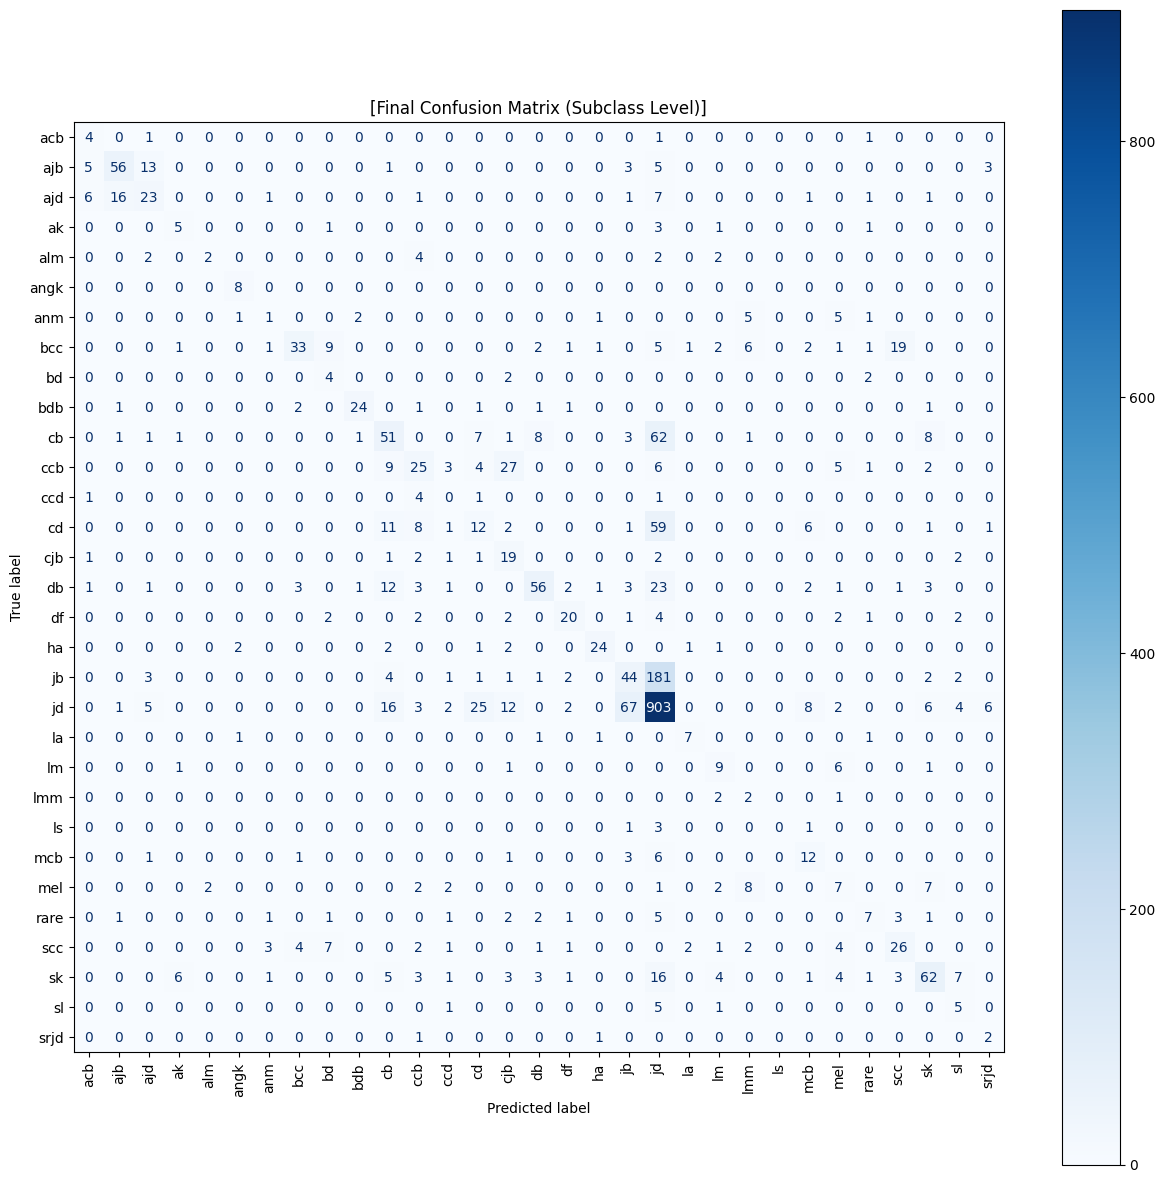


[Subclass Classification Report]
              precision    recall  f1-score   support

         acb     0.2222    0.5714    0.3200         7
         ajb     0.7368    0.6512    0.6914        86
         ajd     0.4600    0.3966    0.4259        58
          ak     0.3571    0.4545    0.4000        11
         alm     0.5000    0.1667    0.2500        12
        angk     0.6667    1.0000    0.8000         8
         anm     0.1250    0.0625    0.0833        16
         bcc     0.7674    0.3882    0.5156        85
          bd     0.1667    0.5000    0.2500         8
         bdb     0.8571    0.7500    0.8000        32
          cb     0.4554    0.3517    0.3969       145
         ccb     0.4098    0.3049    0.3497        82
         ccd     0.0000    0.0000    0.0000         7
          cd     0.2264    0.1176    0.1548       102
         cjb     0.2533    0.6552    0.3654        29
          db     0.7467    0.4912    0.5926       114
          df     0.6452    0.5556    0.5970    

In [ ]:
# PART 6) 최종 테스트 (Final Evaluation with Test Set)
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
import matplotlib.pyplot as plt
import numpy as np

best_model_path = os.path.join(drive_dir, f"multi_head_best_cnn_seed_{seed_num}_lr_{learning_rate}.pth")

model.load_state_dict(torch.load(best_model_path))
model.eval()

total_test_loss = 0.0
y_true_super, y_pred_super = [], []
y_true_main, y_pred_main = [], []
y_true_sub, y_pred_sub = [], []

with torch.no_grad():
    for images, (y_super, y_main, y_sub) in test_loader:
        images = images.to(device)
        y_super = y_super.to(device)
        y_main = y_main.to(device)
        y_sub = y_sub.to(device)

        outputs = model(images)
        loss = hierarchical_loss_balanced(outputs, (y_super, y_main, y_sub))
        total_test_loss += loss.item() * images.size(0)

        out_super, out_main, out_sub = outputs
        preds_super = out_super.argmax(1)
        preds_main = out_main.argmax(1)
        preds_sub = out_sub.argmax(1)

        y_true_super.extend(y_super.cpu().numpy()); y_pred_super.extend(preds_super.cpu().numpy())
        y_true_main.extend(y_main.cpu().numpy()); y_pred_main.extend(preds_main.cpu().numpy())
        y_true_sub.extend(y_sub.cpu().numpy()); y_pred_sub.extend(preds_sub.cpu().numpy())

test_loss = total_test_loss / len(test_loader.dataset)
f1_super = f1_score(y_true_super, y_pred_super, average='macro')
f1_main = f1_score(y_true_main, y_pred_main, average='macro')
f1_sub = f1_score(y_true_sub, y_pred_sub, average='macro')

print("\n[Final Test Results]")
print(f"Hierarchical Test Loss : {test_loss:.4f}")
print(f"Super F1-score (macro): {f1_super:.4f}")
print(f"Main  F1-score (macro): {f1_main:.4f}")
print(f"Sub   F1-score (macro): {f1_sub:.4f}")

idx_to_class = test_dataset.idx_to_class
y_true_names = [idx_to_class[int(i)] for i in y_true_sub]
y_pred_names = [idx_to_class[int(i)] for i in y_pred_sub] # subclass idx -> name mapping

cm = confusion_matrix(y_true_names, y_pred_names, labels=list(idx_to_class.values()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx_to_class.values()))

fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(cmap='Blues', xticks_rotation='vertical', ax=ax)
plt.title("[Final Confusion Matrix (Subclass Level)]")
plt.show()

print("\n[Subclass Classification Report]")
print(classification_report(
    y_true_names,
    y_pred_names,
    labels=list(idx_to_class.values()),
    target_names=list(idx_to_class.values()),
    digits=4,
    zero_division=0
))



In [ ]:
# PART 7) 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()